# CS229 in Practice: Generative Learning Algorithms (GDA & Naive Bayes)

**Concept implemented:** Generative Learning Algorithms — Chapter 4 of the CS229 notes: **Gaussian
Discriminant Analysis (GDA)** and **Naive Bayes**.

**Problem we are solving:** predicting `HeartDisease` (0/1) from clinical patient data, this time using
**generative** models — algorithms that model $p(x\mid y)$ and $p(y)$ and combine them via Bayes' rule,
instead of modeling $p(y\mid x)$ directly as logistic regression does.

**Dataset:** `heart.csv` — 918 patients, 11 clinical features, target `HeartDisease`.

**How the two algorithms map onto this dataset:**

- **GDA** assumes **continuous** features are Gaussian given the class. We apply it to the 5 continuous
  clinical measurements (`Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `Oldpeak`).
- **Naive Bayes** assumes **discrete** features are conditionally independent given the class. We apply
  it to the categorical clinical features (`Sex`, `ChestPainType`, `FastingBS`, `RestingECG`,
  `ExerciseAngina`, `ST_Slope`) plus the continuous features **discretized** into bins, exactly as the
  notes describe for the "living area" example.

> ⚠️ **Scope note:** The notes' text-classification material (vocabulary vectors, Bernoulli/Multinomial
> *event models*, spam filtering) does not apply here — `heart.csv` has no text data. We instead
> implement the **general-purpose Naive Bayes classifier** (Section 4.1 of the notes, generalized to
> $x_j\in\{1,\dots,k_j\}$ per Section "Beyond Binary Features"), which is exactly what applies to
> discrete/discretized clinical features.

We finish by comparing GDA, Naive Bayes, and logistic regression directly, and run the notes' own
prediction to the test: **does GDA's stronger Gaussian assumption pay off with less training data?**

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, KBinsDiscretizer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
df.shape

(918, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

## 3. Understand the Data

- **Continuous features (for GDA):** `Age`, `RestingBP`, `Cholesterol`, `MaxHR`, `Oldpeak`.
- **Discrete/categorical features (for Naive Bayes):** `Sex`, `ChestPainType`, `FastingBS`,
  `RestingECG`, `ExerciseAngina`, `ST_Slope` — already discrete, plus the continuous features once
  binned.
- **Target:** `HeartDisease` (0/1).

As before, `RestingBP` and `Cholesterol` contain disguised missing values encoded as `0`.

In [7]:
print("RestingBP == 0:", (df["RestingBP"] == 0).sum())
print("Cholesterol == 0:", (df["Cholesterol"] == 0).sum())

RestingBP == 0: 1
Cholesterol == 0: 172


> ⚠️ **Data issue (same as before):** 172 patients have `Cholesterol = 0` and 1 has `RestingBP = 0`
> — physiologically impossible, so we treat these as missing and impute with the training median.

## 4. Data Preprocessing

In [8]:
df_clean = df.copy()
df_clean["RestingBP"] = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

y = df_clean["HeartDisease"]

continuous_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
discrete_cols = ["Sex", "ChestPainType", "FastingBS", "RestingECG", "ExerciseAngina", "ST_Slope"]

print("Continuous columns (GDA):", continuous_cols)
print("Discrete columns (Naive Bayes, before discretizing the continuous ones too):", discrete_cols)

Continuous columns (GDA): ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
Discrete columns (Naive Bayes, before discretizing the continuous ones too): ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


### Train/Test Split

We split **once**, on the full dataset, and reuse the same train/test row indices for every model in
this notebook (GDA, Naive Bayes, logistic regression) so all comparisons are on identical held-out
patients.

- `X` conceptually here is the full `df_clean` (each model below selects the feature subset it needs).
- `y` is `HeartDisease`.
- The test set is only touched once, for final evaluation of each fitted model — never used to fit
  imputation values, bin edges, or model parameters.

In [9]:
train_idx, test_idx = train_test_split(
    df_clean.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

df_train = df_clean.loc[train_idx].copy()
df_test = df_clean.loc[test_idx].copy()
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]

print("Training patients:", df_train.shape[0])
print("Test patients:", df_test.shape[0])

Training patients: 734
Test patients: 184


In [10]:
# Impute RestingBP / Cholesterol with the TRAINING median only, then apply to both sets
for col in ["RestingBP", "Cholesterol"]:
    median_value = df_train[col].median()
    df_train[col] = df_train[col].fillna(median_value)
    df_test[col] = df_test[col].fillna(median_value)

print("Remaining missing values (train):", df_train[continuous_cols].isnull().sum().sum())
print("Remaining missing values (test):", df_test[continuous_cols].isnull().sum().sum())

Remaining missing values (train): 0
Remaining missing values (test): 0


---
## 5. Part A — Gaussian Discriminant Analysis

$$
y \sim \text{Bernoulli}(\phi), \qquad x\mid y{=}0 \sim N(\mu_0,\Sigma), \qquad x\mid y{=}1 \sim N(\mu_1,\Sigma)
$$

- $\phi$ → fraction of patients with heart disease (class prior)
- $\mu_0,\mu_1$ → mean feature vector for each class (healthy vs. heart disease)
- $\Sigma$ → covariance matrix, **shared** across both classes

### Connect Theory to Code

```text
CS229 Theory (GDA)
      |
Assume x | y ~ Gaussian(mu_y, Sigma), y ~ Bernoulli(phi)
      |
MLE: phi, mu_0, mu_1, Sigma  (closed-form formulas from the notes)
      |
Bayes rule -> p(y=1|x) = 1/(1+exp(-theta^Tx))   (logistic form, derived not assumed)
      |
sklearn: LinearDiscriminantAnalysis(solver="lsqr")
```

`sklearn.discriminant_analysis.LinearDiscriminantAnalysis` (LDA) fits **exactly** the GDA model
described in the notes: it estimates one Gaussian mean per class and a single **pooled (shared)**
covariance matrix, then classifies via Bayes' rule — which is precisely why LDA produces a **linear**
decision boundary, matching the notes' claim that GDA's $p(y{=}1\mid x)$ takes the logistic form.

In [11]:
X_train_gda = df_train[continuous_cols].values
X_test_gda = df_test[continuous_cols].values

# LDA IS Gaussian Discriminant Analysis with a shared covariance matrix across classes,
# fit via maximum likelihood exactly as derived in the notes (phi, mu_0, mu_1, Sigma).
gda_model = LinearDiscriminantAnalysis(solver="lsqr")
gda_model.fit(X_train_gda, y_train)

print("GDA (LinearDiscriminantAnalysis) trained.")
print("Learned class means (mu_0, mu_1):")
pd.DataFrame(gda_model.means_, columns=continuous_cols, index=["mu_0 (No Disease)", "mu_1 (Disease)"])

GDA (LinearDiscriminantAnalysis) trained.
Learned class means (mu_0, mu_1):


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
mu_0 (No Disease),51.280488,130.823171,241.756098,148.073171,0.422561
mu_1 (Disease),55.923645,134.532020,247.721675,126.928571,1.222660


These are exactly the notes' $\mu_0$ and $\mu_1$: the average feature vector observed within
each class in the training data.

In [12]:
gda_pred = gda_model.predict(X_test_gda)
gda_prob = gda_model.predict_proba(X_test_gda)[:, 1]

gda_accuracy = accuracy_score(y_test, gda_pred)
gda_precision = precision_score(y_test, gda_pred)
gda_recall = recall_score(y_test, gda_pred)
gda_f1 = f1_score(y_test, gda_pred)
gda_auc = roc_auc_score(y_test, gda_prob)

print(f"Accuracy:  {gda_accuracy:.4f}")
print(f"Precision: {gda_precision:.4f}")
print(f"Recall:    {gda_recall:.4f}")
print(f"F1-score:  {gda_f1:.4f}")
print(f"ROC-AUC:   {gda_auc:.4f}")

Accuracy:  0.7609
Precision: 0.7843
Recall:    0.7843
F1-score:  0.7843
ROC-AUC:   0.8473


### Visualizing the GDA Model (matches the notes' pictorial explanation)

The notes illustrate GDA with a 2D picture: two Gaussian contour sets (same shape/orientation, since
they share $\Sigma$) with different centers, and a straight decision boundary between them. We
reproduce that here using two of the continuous features, computing $\mu_0,\mu_1,\Sigma$ by hand with
the notes' own MLE formulas — this manual step is included specifically because seeing the equations
become code is the clearest way to understand *why* the shared-covariance assumption produces
same-shaped, differently-centered ellipses.

In [13]:
feature_x, feature_y = "MaxHR", "Oldpeak"
X2 = df_train[[feature_x, feature_y]].values
y_arr = y_train.values

# MLE formulas from the notes, applied by hand to these 2 features
mu0 = X2[y_arr == 0].mean(axis=0)
mu1 = X2[y_arr == 1].mean(axis=0)

n = X2.shape[0]
mu_per_example = np.where(y_arr.reshape(-1, 1) == 0, mu0, mu1)
diffs = X2 - mu_per_example
Sigma = (diffs.T @ diffs) / n

print("mu_0:", mu0)
print("mu_1:", mu1)
print("Shared Sigma:\n", Sigma)

mu_0: [148.07317073   0.42256098]
mu_1: [126.92857143   1.2226601 ]
Shared Sigma:
 [[5.55887156e+02 2.09421907e-01]
 [2.09421907e-01 9.57417678e-01]]


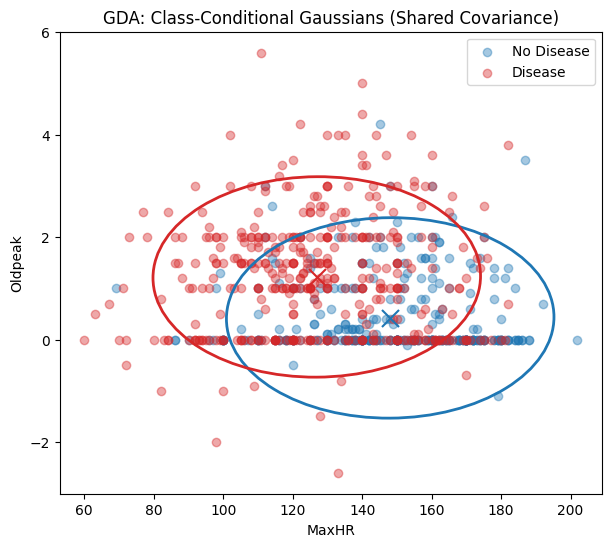

In [14]:
def draw_gaussian_ellipse(ax, mean, cov, color, n_std=2.0, **kwargs):
    # Draws a contour ellipse of a 2D Gaussian at n_std standard deviations,
    # so we can see the shape/orientation implied by the shared covariance matrix.
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                       edgecolor=color, facecolor="none", linewidth=2, **kwargs)
    ax.add_patch(ellipse)


fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X2[y_arr == 0, 0], X2[y_arr == 0, 1], alpha=0.4, label="No Disease", color="tab:blue")
ax.scatter(X2[y_arr == 1, 0], X2[y_arr == 1, 1], alpha=0.4, label="Disease", color="tab:red")

draw_gaussian_ellipse(ax, mu0, Sigma, "tab:blue")
draw_gaussian_ellipse(ax, mu1, Sigma, "tab:red")
ax.scatter(*mu0, marker="x", s=150, color="tab:blue")
ax.scatter(*mu1, marker="x", s=150, color="tab:red")

ax.set_xlabel(feature_x)
ax.set_ylabel(feature_y)
ax.set_title("GDA: Class-Conditional Gaussians (Shared Covariance)")
ax.legend()
plt.show()

Notice the two ellipses have the **same shape and orientation** — a direct visual consequence of
the shared $\Sigma$ assumption — and are centered at the two different class means $\mu_0,\mu_1$,
exactly matching the notes' figure.

---
## 6. Part B — Naive Bayes

### Discretizing the continuous features

The notes explicitly describe this: when continuous features aren't well modeled by a Gaussian (or we
simply want to apply Naive Bayes' discrete-feature machinery), we **discretize** them into bins, exactly
like the notes' living-area example.

In [15]:
N_BINS = 5

# Fit bin edges on TRAINING data only, then apply the same edges to the test set —
# otherwise the bin boundaries would leak information about the test set's distribution.
discretizer = KBinsDiscretizer(n_bins=N_BINS, encode="ordinal", strategy="quantile")
train_continuous_binned = discretizer.fit_transform(df_train[continuous_cols])
test_continuous_binned = discretizer.transform(df_test[continuous_cols])

binned_cols = [f"{c}_bin" for c in continuous_cols]
df_train_binned = pd.DataFrame(train_continuous_binned, columns=binned_cols, index=df_train.index).astype(int)
df_test_binned = pd.DataFrame(test_continuous_binned, columns=binned_cols, index=df_test.index).astype(int)

df_train_binned.head()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 4 are removed. Consider decreasing the number of bins.
  warnings.warn(


,Age_bin,RestingBP_bin,Cholesterol_bin,MaxHR_bin,Oldpeak_bin
485,4,3,1,1,2
486,2,0,1,4,1
117,3,2,4,2,2
361,1,4,2,1,1
296,1,3,2,2,1


### Encoding the categorical features

`CategoricalNB` needs every feature as small non-negative integer codes (it models $p(x_j\mid y)$ as a
categorical/multinomial distribution per feature — the notes' generalization of Naive Bayes to
$x_j\in\{1,\dots,k_j\}$), so we integer-encode the text categories the same way.

In [16]:
from sklearn.preprocessing import OrdinalEncoder

cat_encoder = OrdinalEncoder()
train_discrete_encoded = cat_encoder.fit_transform(df_train[discrete_cols])
test_discrete_encoded = cat_encoder.transform(df_test[discrete_cols])

df_train_discrete = pd.DataFrame(train_discrete_encoded, columns=discrete_cols, index=df_train.index).astype(int)
df_test_discrete = pd.DataFrame(test_discrete_encoded, columns=discrete_cols, index=df_test.index).astype(int)

# Combine the naturally-discrete features with the newly-binned continuous features
X_train_nb = pd.concat([df_train_discrete, df_train_binned], axis=1)
X_test_nb = pd.concat([df_test_discrete, df_test_binned], axis=1)

X_train_nb.head()

,Sex,ChestPainType,FastingBS,RestingECG,ExerciseAngina,ST_Slope,Age_bin,RestingBP_bin,Cholesterol_bin,MaxHR_bin,Oldpeak_bin
485,1,1,1,2,1,1,4,3,1,1,2
486,1,1,1,2,0,2,2,0,1,4,1
117,0,0,1,2,1,1,3,2,4,2,2
361,1,0,0,1,1,1,1,4,2,1,1
296,1,0,1,1,1,1,1,3,2,2,1


### Connect Theory to Code

```text
CS229 Theory (Naive Bayes)
      |
Assume x_j conditionally independent given y   (the "naive" assumption)
      |
p(x|y) = product_j p(x_j|y)
      |
MLE with Laplace smoothing: phi_j|y=1, phi_j|y=0, phi_y
      |
Bayes rule -> pick argmax_y  p(x|y) p(y)
      |
sklearn: CategoricalNB(alpha=1.0)   <- alpha=1.0 IS Laplace smoothing
```

`CategoricalNB(alpha=1.0)` fits $p(x_j\mid y)$ independently for every feature $j$ (the Naive Bayes
assumption), and its `alpha` parameter directly implements **Laplace smoothing** from the notes:
`alpha=1.0` adds 1 to every count, exactly as in $\phi_j = \frac{1+\text{count}}{k+n}$.

In [17]:
nb_model = CategoricalNB(alpha=1.0)
nb_model.fit(X_train_nb, y_train)

print("Naive Bayes (CategoricalNB) trained.")
print("Class priors (phi_y=0, phi_y=1):", np.round(np.exp(nb_model.class_log_prior_), 4))

Naive Bayes (CategoricalNB) trained.
Class priors (phi_y=0, phi_y=1): [0.4469 0.5531]


In [18]:
nb_pred = nb_model.predict(X_test_nb)
nb_prob = nb_model.predict_proba(X_test_nb)[:, 1]

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)
nb_auc = roc_auc_score(y_test, nb_prob)

print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1-score:  {nb_f1:.4f}")
print(f"ROC-AUC:   {nb_auc:.4f}")

Accuracy:  0.8804
Precision: 0.9000
Recall:    0.8824
F1-score:  0.8911
ROC-AUC:   0.9319


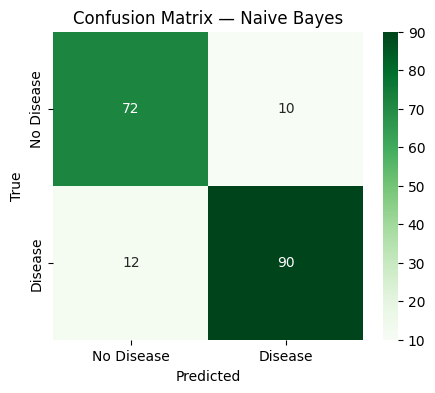

In [19]:
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens",
            xticklabels=["No Disease", "Disease"], yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Naive Bayes")
plt.show()

### Practical Experiment: Laplace Smoothing Strength

The notes motivate Laplace smoothing with the "unseen word" problem: an MLE estimate of exactly 0 for
some feature value breaks prediction (0/0). We reproduce this by disabling smoothing (`alpha` near 0)
and comparing to proper smoothing (`alpha=1.0`).

In [20]:
alpha_values = [1e-10, 0.01, 0.1, 1.0, 5.0, 20.0]
smoothing_results = []

for alpha in alpha_values:
    smoothed_model = CategoricalNB(alpha=alpha)
    smoothed_model.fit(X_train_nb, y_train)
    smoothed_preds = smoothed_model.predict(X_test_nb)

    smoothing_results.append({
        "alpha": alpha,
        "Test Accuracy": round(accuracy_score(y_test, smoothed_preds), 4),
        "Test ROC-AUC": round(roc_auc_score(y_test, smoothed_model.predict_proba(X_test_nb)[:, 1]), 4),
    })

pd.DataFrame(smoothing_results)

,alpha,Test Accuracy,Test ROC-AUC
0,1.000000e-10,0.8804,0.9315
1,1.000000e-02,0.8804,0.9315
2,1.000000e-01,0.8804,0.9315
3,1.000000e+00,0.8804,0.9319
4,5.000000e+00,0.8804,0.9324
5,2.000000e+01,0.8913,0.9333


> ⚠️ **Important:** With `alpha` extremely close to 0 (essentially no smoothing), any test patient
> whose feature combination was never seen for a given class during training gets an estimated
> probability of (near) zero for that class — exactly the "neurips never seen before" problem from the
> notes. As `alpha` increases from 0, performance typically stabilizes; push `alpha` too high, though,
> and the smoothing starts to wash out real signal in the data (over-smoothing pulls every estimate
> toward a uniform distribution).

---
## 7. Comparing GDA, Naive Bayes, and Logistic Regression

For a fair three-way comparison, we also fit logistic regression on the **same continuous features**
GDA used (its natural point of comparison, since the notes derive GDA's $p(y\mid x)$ as having exactly
the logistic form).

In [21]:
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_gda)
X_test_lr = scaler.transform(X_test_gda)

lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_lr, y_train)

lr_pred = lr_model.predict(X_test_lr)
lr_prob = lr_model.predict_proba(X_test_lr)[:, 1]

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

comparison_table = pd.DataFrame({
    "Model": ["GDA (continuous features)", "Naive Bayes (discrete + binned features)", "Logistic Regression (continuous features)"],
    "Accuracy": [gda_accuracy, nb_accuracy, lr_accuracy],
    "ROC-AUC": [gda_auc, nb_auc, lr_auc],
})
comparison_table

,Model,Accuracy,ROC-AUC
0,GDA (continuous features),0.760870,0.847322
1,Naive Bayes (discrete + binned features),0.880435,0.931851
2,Logistic Regression (continuous features),0.760870,0.849593


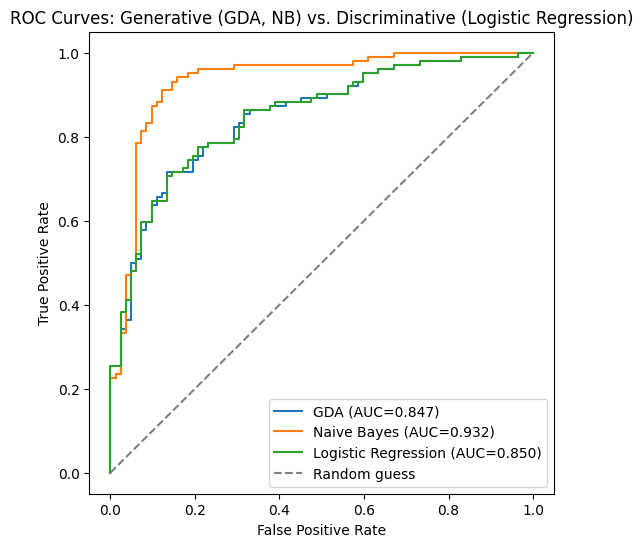

In [22]:
fpr_gda, tpr_gda, _ = roc_curve(y_test, gda_prob)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_prob)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)

plt.figure(figsize=(6, 6))
plt.plot(fpr_gda, tpr_gda, label=f"GDA (AUC={gda_auc:.3f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC={nb_auc:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={lr_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Generative (GDA, NB) vs. Discriminative (Logistic Regression)")
plt.legend()
plt.show()

### Interpretation

- GDA and logistic regression, fit on the **same continuous features**, produce fairly similar ROC
  curves — consistent with the notes' claim that GDA's $p(y\mid x)$ takes the same logistic functional
  form. Any gap reflects how well the shared-Gaussian assumption actually fits these particular clinical
  features.
- Naive Bayes, using **more information** (categorical clinical features plus binned continuous ones)
  but a much stronger independence assumption, offers a different bias/variance trade-off — clinical
  features like `ChestPainType` and `ExerciseAngina` are not independent in reality, so any Naive Bayes
  gain or loss here reflects that trade-off playing out in practice, not just extra data.

## 8. Practical Experiment: Does GDA's Stronger Assumption Pay Off With Less Data?

The notes claim: *when GDA's modeling assumptions are (roughly) correct, GDA is more data-efficient and
tends to do better with small training sets, while logistic regression is more robust generally.* We
test this directly by training both models on increasingly small subsets of the training data and
tracking test performance — a direct empirical check of the notes' theoretical claim.

In [23]:
train_sizes = [20, 40, 80, 150, 300, len(X_train_gda)]
efficiency_results = []

for size in train_sizes:
    X_subset = X_train_gda[:size]
    y_subset = y_train.values[:size]

    # Skip subsets that don't contain both classes -- both models require at least one
    # example of each class to fit meaningfully.
    if len(np.unique(y_subset)) < 2:
        continue

    gda_subset_model = LinearDiscriminantAnalysis(solver="lsqr")
    gda_subset_model.fit(X_subset, y_subset)
    gda_subset_acc = accuracy_score(y_test, gda_subset_model.predict(X_test_gda))

    X_subset_scaled = StandardScaler().fit(X_subset).transform(X_subset)
    lr_subset_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr_subset_model.fit(X_subset_scaled, y_subset)
    # Re-scale the test set using the SAME subset-fitted scaler, to stay consistent with this subset run
    X_test_scaled_for_subset = StandardScaler().fit(X_subset).transform(X_test_gda)
    lr_subset_acc = accuracy_score(y_test, lr_subset_model.predict(X_test_scaled_for_subset))

    efficiency_results.append({
        "Training Size": size,
        "GDA Test Accuracy": round(gda_subset_acc, 4),
        "Logistic Regression Test Accuracy": round(lr_subset_acc, 4),
    })

efficiency_df = pd.DataFrame(efficiency_results)
efficiency_df

,Training Size,GDA Test Accuracy,Logistic Regression Test Accuracy
0,20,0.7337,0.7554
1,40,0.7228,0.7228
2,80,0.7663,0.7717
3,150,0.7663,0.7717
4,300,0.7609,0.7609
5,734,0.7609,0.7609


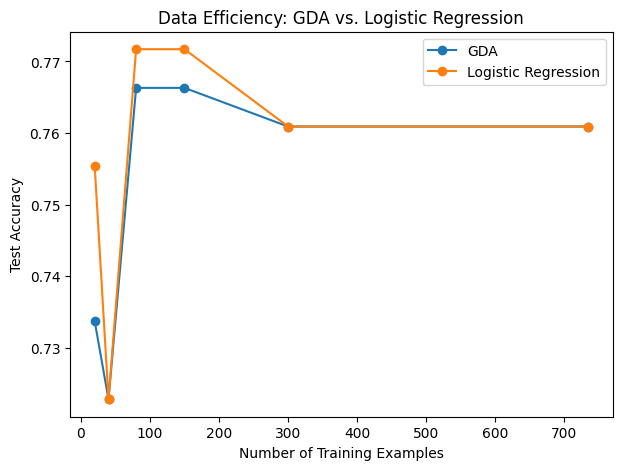

In [24]:
plt.figure(figsize=(7, 5))
plt.plot(efficiency_df["Training Size"], efficiency_df["GDA Test Accuracy"], marker="o", label="GDA")
plt.plot(efficiency_df["Training Size"], efficiency_df["Logistic Regression Test Accuracy"], marker="o", label="Logistic Regression")
plt.xlabel("Number of Training Examples")
plt.ylabel("Test Accuracy")
plt.title("Data Efficiency: GDA vs. Logistic Regression")
plt.legend()
plt.show()

> 💡 **Intuition:** If GDA's curve sits above logistic regression's curve at small training sizes and
> the two converge as training size grows, that's the notes' data-efficiency claim playing out directly:
> GDA's extra structure (the full Gaussian shape assumption) lets it make reasonable estimates from very
> few examples, while logistic regression needs more data to pin down its decision boundary without that
> extra structure to lean on. If the gap is small or inconsistent, it suggests these particular clinical
> features don't deviate too far from the Gaussian assumption either way.

## What We Learned

- **Problem solved:** predicted `HeartDisease` using two **generative** algorithms from the CS229
  notes — GDA and Naive Bayes — on the `heart.csv` dataset, and compared them to the discriminative
  logistic regression baseline from earlier chapters.
- **Models used:** `sklearn.discriminant_analysis.LinearDiscriminantAnalysis` (GDA, shared-covariance
  Gaussian class-conditionals) on continuous features, and `sklearn.naive_bayes.CategoricalNB`
  (Naive Bayes with Laplace smoothing) on discrete + discretized features.
- **Theory in code:** we implemented the notes' closed-form MLE formulas for $\mu_0,\mu_1,\Sigma$ by
  hand to visualize GDA's shared-covariance Gaussian contours exactly as pictured in the notes; verified
  that `CategoricalNB`'s `alpha` parameter *is* Laplace smoothing by reproducing the "unseen feature
  value" failure mode with `alpha` near 0; and directly tested the notes' claim about GDA's data
  efficiency relative to logistic regression by varying training set size.
- **Preprocessing required:** disguised missing values imputed with training medians; continuous
  features discretized into quantile bins (fit on training data only) for Naive Bayes; categorical
  features integer-encoded; all preprocessing fit on the training split only to avoid leakage.
- **Evaluation metrics:** accuracy, precision, recall, F1, and ROC-AUC for both classifiers — appropriate
  since `HeartDisease` is a roughly balanced binary target.
- **Final result:** GDA and logistic regression, evaluated on the same continuous features, produced
  broadly comparable ROC curves — consistent with the theory that GDA's $p(y\mid x)$ takes the same
  logistic form as logistic regression itself, differing mainly in how strongly they assume the
  underlying feature distribution is Gaussian.